In [4]:
from importlib.metadata import version
import torch
import torch.nn as nn
from pathlib import Path
#from .previous_chapters import MultiHeadAttention 

PATH_VECS = Path('../datasets/context_vecs.pt')

context_vecs = torch.load(PATH_VECS)

#print(context_vecs[:10])

# Visualisierung der Context Vektoren

Die Visualisierung zeigt die vorberechneten Context Vektoren aus context_vecs.pt 
als Heatmap. Die Y-Achse zeigt die Token Positionen, die X-Achse die 
256 Embedding Dimensionen. Jede Zeile weist einen charakteristischen 
Farbverlauf auf, was die unterschiedliche Vektorrepräsentation der 
einzelnen Tokens verdeutlicht. Da der Embedding-Layer zu Beginn zufällig 
initialisiert wird, erlangen die Gewichte erst durch das Training 
semantische Bedeutung.

Vektoren plotten

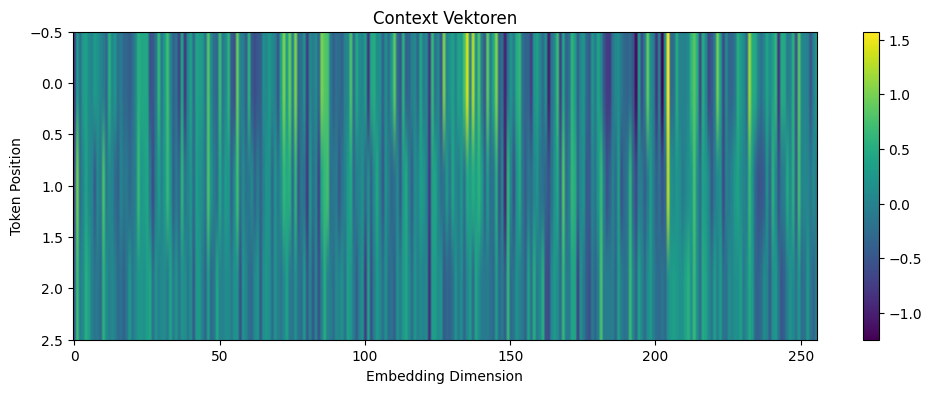

In [5]:
import matplotlib.pyplot as plt

vector_in_array = context_vecs[0].detach().numpy()

def context_vector_plot(x):
    plt.figure(figsize=(12,4))
    plt.imshow(x, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("Context Vektoren")
    plt.xlabel("Embedding Dimension")
    plt.ylabel("Token Position")
    plt.show()

if __name__ == '__main__':
    context_vector_plot(vector_in_array)

# Konfiguration des GPT-Modells

Die Konfiguration wird als Dictionary definiert, sodass alle Hyperparameter 
zentral verwaltet und wiederverwendet werden können.

## Parameter

vocab_size definiert die Anzahl der Tokens des cl100k_base Tokenizers.

context_length gibt die maximale Sequenzlänge an, die das Modell 
gleichzeitig verarbeiten kann. GPT-2 wurde mit 1024 Tokens trainiert.

emb_dim legt fest dass jedes Token als Vektor mit 768 Dimensionen 
dargestellt wird, wobei jede Dimension einen semantischen Aspekt des 
Tokens kodiert.

n_heads definiert die Anzahl der Attention-Heads. Jeder Head betrachtet 
den Text aus einem anderen Blickwinkel. Mit 768 ÷ 12 = 64 Dimensionen 
pro Head.

n_layers gibt die Anzahl der hintereinandergeschalteten TransformerBlöcke an.

drop_rate schaltet während des Trainings zufällig 10% der Verbindungen 
aus um Overfitting zu vermeiden.

qkv_bias deaktiviert den zusätzlichen Bias-Parameter in der Attention, 
was dem Standard moderner Sprachmodelle entspricht.

In [6]:
GPT_CONFIG = {
    "vocab_size": 100277,       # cl100k_base Vokabulargröße
    "context_length": 1024,     # maximale Sequenzlänge
    "emb_dim": 768,             # Embedding Dimension
    "n_heads": 12,              # Anzahl Attention Heads
    "n_layers": 12,             # Anzahl TransformerBlocks
    "drop_rate": 0.1,           # Dropout Rate
    "qkv_bias": False           # kein Bias in Attention
}



# Layer Normalisierung

Implementierung der LayerNorm Klasse zur Stabilisierung der Aktivierungen 
im Modell. Nach der Attention können die Aktivierungen sehr große oder 
sehr kleine Werte annehmen, was das Training destabilisiert. LayerNorm 
normalisiert die Werte auf einen einheitlichen Bereich mit Mittelwert 0 
und Varianz 1.

## Parameter

eps verhindert eine Division durch Null bei der Varianzberechnung.

scale und shift sind lernbare Parameter die während des Trainings 
angepasst werden, um die optimale Skalierung und Verschiebung der 
normalisierten Werte zu erlernen.

In [7]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

# GELU Aktivierungsfunktion

Implementierung der GELU Aktivierungsfunktion (Gaussian Error Linear Unit). 
Aktivierungsfunktionen ermöglichen dem Modell nicht-lineare Zusammenhänge 
zu erlernen — ohne sie wäre das Modell unabhängig von der Anzahl der 
Schichten auf lineare Transformationen beschränkt.

## Vergleich mit ReLU

Im Gegensatz zu ReLU (Rectified Linear Unit), welche negative Werte 
hart auf 0 setzt, dämpft GELU negative Werte sanft und kontinuierlich. 
Dies führt zu einem stabileren Gradientenfluss während des Trainings 
und besseren Ergebnissen bei Sprachmodellen. Da GPT-2 mit GELU trainiert 
wurde, wird diese Aktivierungsfunktion auch hier verwendet.

In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

## Visualisierung GELU vs ReLU

Der Plot vergleicht den Verlauf beider Aktivierungsfunktionen im Wertebereich 
von -3 bis 3. Während ReLU negative Werte hart auf 0 setzt und einen 
abrupten Knick bei x=0 aufweist, zeigt GELU einen weichen und 
kontinuierlichen Übergang mit einem kleinen negativen Bereich bei 
approximately x=-0.75. Dieser leicht negative Anteil ermöglicht einen 
besseren Gradientenfluss für negative Eingabewerte.

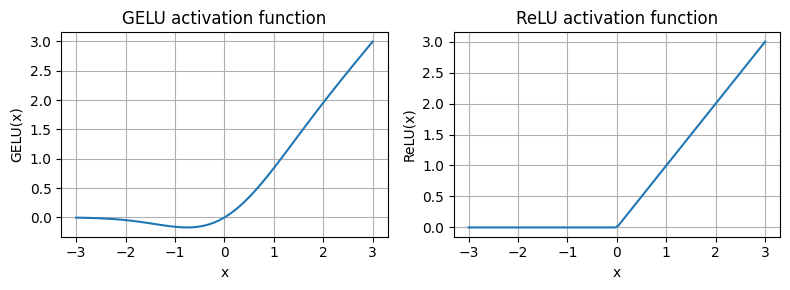

In [ ]:

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

if __name__ == '__main__':

    plt.figure(figsize=(8, 3))
    for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
        plt.subplot(1, 2, i)
        plt.plot(x, y)
        plt.title(f"{label} activation function")
        plt.xlabel("x")
        plt.ylabel(f"{label}(x)")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# FeedForward Netzwerk

Implementierung des FeedForward Netzwerks, welches nach der Attention 
auf jeden Token individuell angewendet wird. Dies erhöht die Kapazität 
des Modells komplexe sprachliche Muster zu erlernen.

## Architektur

Die erste Linear-Schicht weitet die Embedding Dimension von 768 auf 
3072 (4 × emb_dim) auf. Dieser erweiterte Zwischenraum ermöglicht 
dem Modell eine reichhaltigere Repräsentation der Eingabe zu erlernen. 
Anschließend wird GELU als Aktivierungsfunktion angewendet um 
Nicht-Linearität einzuführen. Die zweite Linear-Schicht reduziert 
die Dimension wieder auf 768 zurück, sodass die Ausgabe die gleiche 
Form wie die Eingabe besitzt.

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)



# TransformerBlock

Der TransformerBlock bildet das zentrale Bauteil des GPT-Modells und 
kombiniert alle zuvor implementierten Komponenten. Er wird 12 mal 
sequenziell hintereinandergeschaltet, wobei jeder Block das kontextuelle 
Verständnis des Textes schrittweise vertieft.

## Architektur

Der Block besteht aus zwei identisch aufgebauten Teilbereichen. Im ersten 
Teil wird LayerNorm zur Stabilisierung angewendet, gefolgt von der 
MultiHeadAttention aus Lab 3 und abschließend Dropout zur Regularisierung. 
Der zweite Teil wiederholt dieses Schema mit FeedForward anstelle der Attention.

## Shortcut Connections

Nach jedem Teilbereich wird der ursprüngliche Input wieder auf die 
Ausgabe addiert (Residualverbindung). Diese Shortcut Connections verhindern 
das Vanishing Gradient Problem bei tiefen Netzwerken, da der Gradient 
einen direkten Pfad durch das Netzwerk zurückfließen kann.

In [ ]:
#sys.path.append('../ch04/01_main-chapter-code/')
import sys
sys.path.append('../ch04/01_main-chapter-code')
from previous_chapters import MultiHeadAttention  # pyright: ignore[reportMissingImports]

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

# GPT Modell

Das GPTModel vereint alle zuvor implementierten Bausteine zu einem 
vollständigen Sprachmodell. Token IDs werden zunächst durch tok_emb 
in Vektoren umgewandelt und durch pos_emb mit Positionsinformationen 
angereichert. Beide Embeddings werden addiert und durch Dropout 
regularisiert, bevor die Daten sequenziell durch 12 TransformerBlöcke 
verarbeitet werden. Abschließend normalisiert LayerNorm die Aktivierungen 
und die finale Linear-Schicht gibt für jedes Token eine Wahrscheinlichkeit 
über das gesamte Vokabular von 100277 Tokens aus.

## Modellgrößen im Vergleich

Da cl100k_base ein größeres Vokabular als der originale GPT-2 Tokenizer 
verwendet (100277 statt 50257 Tokens), weisen alle Modellvarianten 
eine höhere Parameteranzahl auf. Die Parameteranzahl und der 
Speicherbedarf skalieren dabei mit der Embedding Dimension und 
der Anzahl der TransformerBlöcke.

## Weight Tying

Ohne Weight Tying teilen Token Embedding und Output Layer keine 
Gewichte, was zu einer höheren Parameteranzahl führt. Bei Anwendung 
von Weight Tying würden beide Schichten dieselbe Gewichtsmatrix 
verwenden und die Parameteranzahl reduzieren.

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

configs = {
    "GPT-2 Small":  {"emb_dim": 768,  "n_heads": 12, "n_layers": 12},
    "GPT-2 Medium": {"emb_dim": 1024, "n_heads": 16, "n_layers": 24},
    "GPT-2 Large":  {"emb_dim": 1280, "n_heads": 20, "n_layers": 36},
    "GPT-2 XL":     {"emb_dim": 1600, "n_heads": 25, "n_layers": 48},
}

for name, cfg in configs.items():
    config = GPT_CONFIG.copy()
    config.update(cfg)
    m = GPTModel(config)
    total = sum(p.numel() for p in m.parameters())
    print(f"{name}: {total:,} Parameter, {total*4/(1024*1024):.0f} MB")

model = GPTModel(GPT_CONFIG)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

total_size_mb = total_params * 4/(1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

GPT-2 Small: 239,840,256 Parameter, 915 MB
GPT-2 Medium: 508,653,568 Parameter, 1940 MB
GPT-2 Large: 966,272,000 Parameter, 3686 MB
GPT-2 XL: 1,797,856,000 Parameter, 6858 MB
Total number of parameters: 239,840,256
Number of trainable parameters considering weight tying: 162,827,520
Total size of the model: 914.92 MB


# Visualisierung der Modellausgabe (Logits)

Der Plot zeigt die Logits des untrainierten GPT-Modells für den 
Eingabekontext "Recepie:". Die Logits repräsentieren die Rohausgabe 
des Modells vor der Softmax-Funktion und geben für jedes Token im 
Vokabular einen Wahrscheinlichkeitswert an.

## Interpretation

Die Y-Achse zeigt die Token Positionen des Eingabetextes, die X-Achse 
die 100277 möglichen nächsten Tokens des Vokabulars. Da das Modell 
zu diesem Zeitpunkt noch untrainiert ist und zufällig initialisierte 
Gewichte besitzt, sind die Logits gleichmäßig verteilt ohne erkennbare 
Muster. Erst durch das Training in Lab 5 lernt das Modell sinnvolle 
Wahrscheinlichkeitsverteilungen zu erzeugen und das wahrscheinlichste 
nächste Token korrekt vorherzusagen.

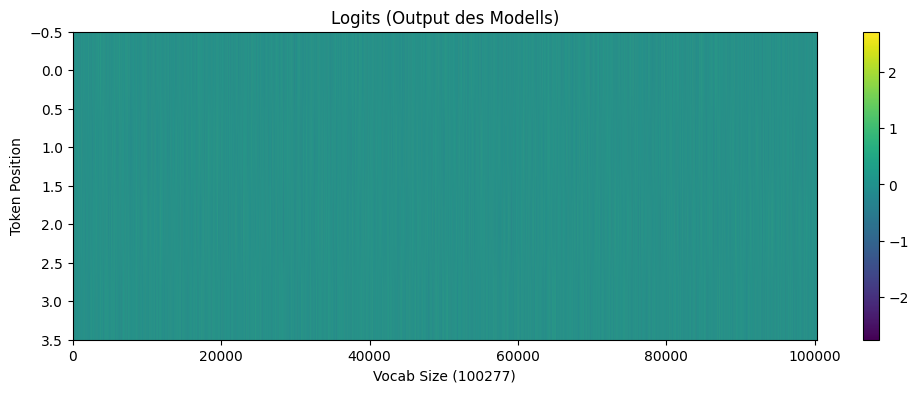

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("cl100k_base")

start_context = "Recepie:"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # [1, seq_len]

model = GPTModel(GPT_CONFIG)
model.eval()

with torch.no_grad():
    output = model(encoded_tensor)

if __name__ == '__main__':

    plt.figure(figsize=(12, 4))
    plt.imshow(output[0].detach().numpy(), aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("Logits (Output des Modells)")
    plt.xlabel("Vocab Size (100277)")
    plt.ylabel("Token Position")
    plt.show()

# Textgenerierung

Implementierung der generate_text_simple Funktion zur Textgenerierung 
mittels Greedy Decoding. In jedem Schritt wird das Token mit der 
höchsten Wahrscheinlichkeit als nächstes Token ausgewählt und an 
die bestehende Sequenz angehängt.

## Parameter

**idx** enthält den Eingabetext als Token IDs.  
**max_new_tokens** definiert die Anzahl der zu generierenden Tokens.  
**context_size** begrenzt die Eingabe auf die letzten 1024 Tokens 
falls die Sequenz die maximale Kontextlänge überschreitet.

## Funktionsweise

In jedem Iterationsschritt wird der Eingabekontext auf context_size 
gekürzt und durch das Modell verarbeitet. Mittels Softmax werden die 
Logits in Wahrscheinlichkeiten umgewandelt und das wahrscheinlichste 
Token per argmax ausgewählt. torch.no_grad() deaktiviert die 
Gradientenberechnung da keine Gewichtsaktualisierung stattfindet. 
Da das Modell zu diesem Zeitpunkt untrainiert ist, ergibt der 
generierte Text noch keinen semantischen Sinn.

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [ ]:
import os
os.makedirs('../../datasets', exist_ok=True)

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG)

torch.save(model.state_dict(), '../../datasets/model.pt')